In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score

## Conjunto de datos
Dataset: https://www.kaggle.com/datasets/juanagsolano/penguins-v1

In [2]:
pin = pd.read_csv('penguins_v1.csv')
df = pd.DataFrame(pin)
df.head()

,id,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,1,1,39.1,18.7,181,3750,1,2007
1,2,1,1,39.5,17.4,186,3800,0,2007
2,3,1,1,40.3,18.0,195,3250,0,2007
3,5,1,1,36.7,19.3,193,3450,0,2007
4,6,1,1,39.3,20.6,190,3650,1,2007


### Tipos de datos
Se exploran los tipos de datos de cada variable del conjunto de datos. Se tiene un total de 8 variables, todas numericas, donde se indica la especie del pingüino donde  1 = "Adelie", 2 = "Gentoo", 3 = "Chinstrap", se indica la isla de donde proviene donde  1 = "Torgersen", 2 = "Biscoe", 3 = "Dream", longitud del pico en mm, profundidad del pico en mm, longitud de la aleta en mm, peso en gramos, y año en que se tomo la medición.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 333 non-null    int64  
 1   species            333 non-null    int64  
 2   island             333 non-null    int64  
 3   bill_length_mm     333 non-null    float64
 4   bill_depth_mm      333 non-null    float64
 5   flipper_length_mm  333 non-null    int64  
 6   body_mass_g        333 non-null    int64  
 7   sex                333 non-null    int64  
 8   year               333 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 23.5 KB


### Variable objetivo
Se elige como variable objetivo o variable dependiente a "specias", de manera que el resto de las variables son los valores de X, es decir, las variables independientes.
Se establece la columna de y. Se establecen las columnas para X usando drop para eliminar la variable objetivo

In [4]:
y = df['species']
X = df.drop(columns=['species'])

### Revisar valores nulos
Se hace la revisión de la existencia de valores nulos en los datos. Se usa la función insull la cual detecta si hay valores nulos del tipo NaN o None en un DataFrame o una serie, si es nulo entonces devuelve True, de lo contrario devuelve False. También, se usa sum() que devuelve la sumatoria de un iterable.

In [5]:
df.isnull().sum()

id                   0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64

## Función principal
Se realiza una función para entrenar el árbol de desición con el criterio Gini y Entropía. Se reciben como parámetros test_tam el cual refiere al tamaño de prueba para dividir los datos. También, se recibe la profundidad del árbol, y la cadena del titulo para poder diferenciarlos.   

### División de datos
Se hace la división de datos de entrenamiento y de prueba usando la función train_test_split, la cual devuelve el conjunto de entrenamiento para X, el conjunto de prueba para X, el conjunto de entrenamiento para y, el conjunto de prueba para y. Recibe como parámetro a las variables independientes, la vaariable dependiente, el tamaño de prueba, y la semilla aleatoria.   

### Criterios
Medidas usadas para decidir como dividir los datos en ramas. 
#### Criterio Gini
Revisa la frecuencia con la que una muestra aleatoria se etiquetaria de manera incorrecta si se asignara por probabilidad de clase. Es el cirterio que usa por defecto sklearn
$$Gini = 1 -\sum_{i=1}^n p_ilog_2(p_i)$$
$p_i$: Probabilidad de la clase
Entre menor sea el valor del nodo, entonces los nodos son más homogéneos.
#### Entropía
Mide la incertidumbre en la distribución de clases de un nodo. Entre mayor entropía hay mayor desorden entre las etiquetas de clase.
$$Entropia = -\sum_{i=1}^n p_i log_2(p_i)$$

### Entrenamiento del árbol de desición
Los árboles de desición y bosques aleatorios son algoritmos basados en reglas para aproximizar relaciones en datos estructurados. Se manda a llamar la clase DecisionTreeClassifier donde se recibe la profundidad del árbol y la semilla de aleatoridad. El método fit entrena el modelo con el conjunto de entrenamiento de X y el conjunto de entrenamiento de y.

### Métricas
Precisión: Mide que tan preciso es el modelo al hacer predicciones positivas.
$$Precision=\frac{True Positive}{True Positive + False Positive}$$
True Positive: Casos correctamente clasificados como positivos.    
False Positive: Casos incorrectamente clasificados como positivos.    
Sensibilidad o exhaustividad (Recall): Mide qué porcentaje de los casos positivos fueron detectados correctamente.   
$$Recall = \frac{True Positive}{True Positive + False Negatives}$$
False Negative: Casos positivos en que el modelo clasificó como negativos.   
F1- Score: Métrica combinada que busca equilibrar la presición y el recall.  
$$F1 = 2(\frac{(Precision)(Recall)}{(Precision + Recall)})$$
Suport: Indica el número de instancias reales de cada clase en los datos de prueba.

En este caso, como se tienen tres clases en la variable dependiente, se usa average='weighted' para calcular el promedio ponderado, y se usa zero_division=0 para controlar las divisiones entre 0, asignando el valor de 0.


In [24]:
def arbol(test_tam, profundidad, titulo):
    print(titulo)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= test_tam, random_state=42) #Division de datos
    print(f"Muestras de entrenamiento X: {len(X_train)}")
    print(f"Muestras de prueba X: {len(X_test)}")
    print(f"Muestras de entrenamiento y: {len(y_train)}")
    print(f"Muestras de prueba y: {len(y_test)}")

    clf = DecisionTreeClassifier(max_depth= profundidad, random_state=42) #Classe del árbol de decisión
    clf.fit(X_train, y_train) #Entrenamiento del árbol

    y_pred = clf.predict(X_test) # y predichas

    plt.figure(figsize=(8,5)) #Gráfica de árbol
    plot_tree(clf, filled=True, feature_names=X_train.columns)
    plt.title(f'Criterio de Gini para {titulo}')
    plt.show()

    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0) #Métricas
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    support = df['species'].value_counts()
    print(f'Precisión: {precision:.2f}')
    print(f'Recall: {recall}')
    print(f'F1: {f1}')
    print(f'Support: {support}')

    clf_entropia = DecisionTreeClassifier(max_depth= profundidad, random_state=42,criterion='entropy') #Árbol con el criterio de entropía
    clf_entropia.fit(X_train, y_train)
    
    y_pred_entropia = clf_entropia.predict(X_test)

    plt.figure(figsize=(8,5))
    plot_tree(clf_entropia, filled=True, feature_names=X_train.columns)
    plt.title(f'Criterio de entropía para {titulo}')
    plt.show()

    precision_entropia = precision_score(y_test, y_pred_entropia, average='weighted', zero_division=0)
    recall_entropia = recall_score(y_test, y_pred_entropia, average='weighted', zero_division=0)
    f1_entropia = f1_score(y_test, y_pred_entropia, average='weighted', zero_division=0)
    support = df['species'].value_counts()
    print(f'Precisión: {precision_entropia:.2f}')
    print(f'Recall: {recall_entropia}')
    print(f'F1: {f1_entropia}')
    print(f'Support: {support}')


## Árboles con división 90-10

Se entrena el primer árbol considerando la división de entrenamiento y prueba de 90-10 y produndidad del árbol igual a 1.

Arbol de decisión 90-10 y produndidad = 1
Muestras de entrenamiento X: 299
Muestras de prueba X: 34
Muestras de entrenamiento y: 299
Muestras de prueba y: 34


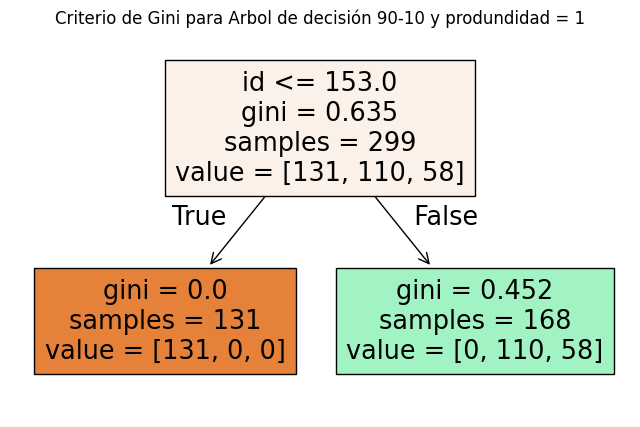

Precisión: 0.53
Recall: 0.6764705882352942
F1: 0.583807716635041
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


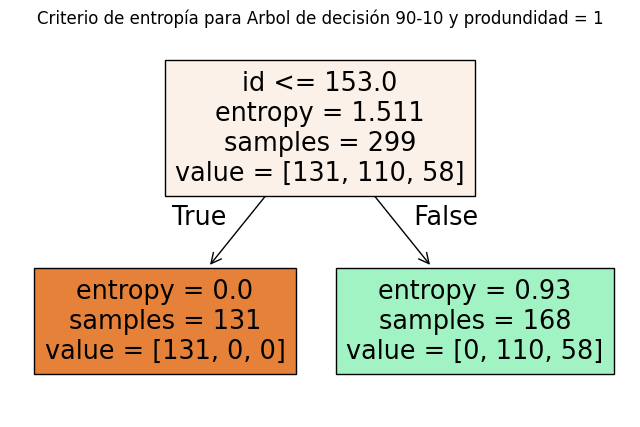

Precisión: 0.53
Recall: 0.6764705882352942
F1: 0.583807716635041
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [25]:
arbol1 = arbol(0.10, 1, 'Arbol de decisión 90-10 y produndidad = 1')

Se entrena el segundo árbol considerando la división de entrenamiento y prueba de 90-10 y produndidad del árbol igual a 2.

Arbol de decisión 90-10 y produndidad = 2
Muestras de entrenamiento X: 299
Muestras de prueba X: 34
Muestras de entrenamiento y: 299
Muestras de prueba y: 34


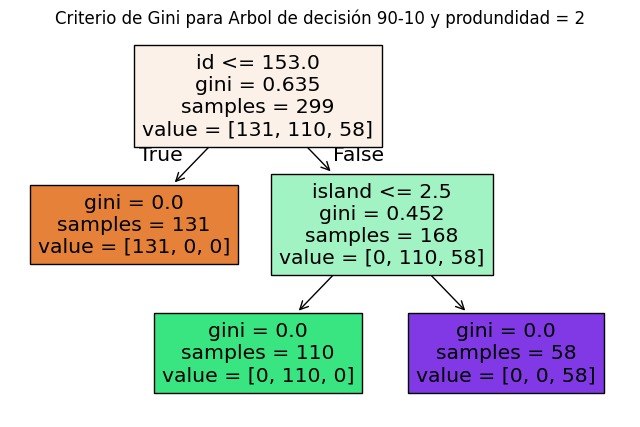

Precisión: 0.97
Recall: 0.9705882352941176
F1: 0.9701975666927112
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


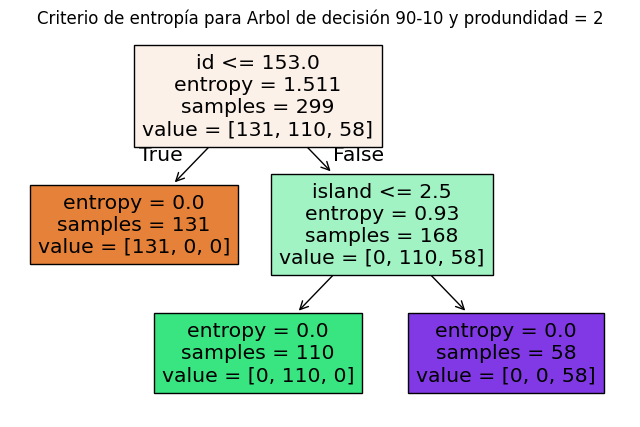

Precisión: 0.97
Recall: 0.9705882352941176
F1: 0.9701975666927112
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [27]:
arbol2 = arbol(0.10, 2, 'Arbol de decisión 90-10 y produndidad = 2')

In [ ]:
Se entrena el tercer árbol considerando la división de entrenamiento y prueba de 90-10 y produndidad del árbol igual a 3.

Arbol de decisión 90-10 y produndidad = 3
Muestras de entrenamiento X: 299
Muestras de prueba X: 34
Muestras de entrenamiento y: 299
Muestras de prueba y: 34


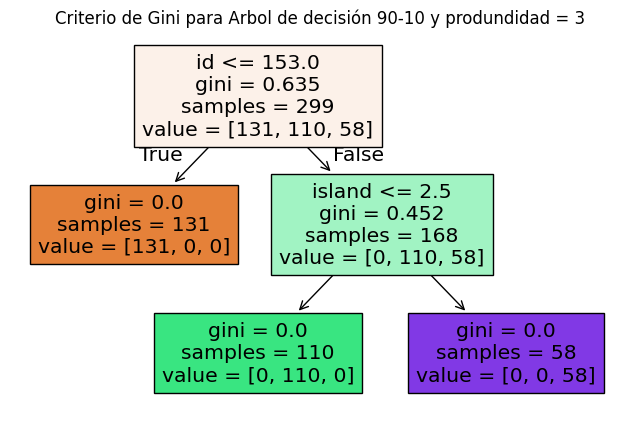

Precisión: 0.97
Recall: 0.9705882352941176
F1: 0.9701975666927112
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


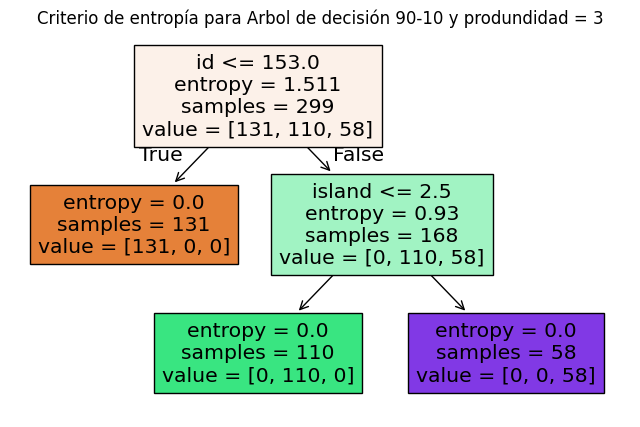

Precisión: 0.97
Recall: 0.9705882352941176
F1: 0.9701975666927112
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [29]:
arbol3 = arbol(0.10, 3, 'Arbol de decisión 90-10 y produndidad = 3')

## Árboles con división 80-20

Se entrena el primer árbol considerando la división de entrenamiento y prueba de 80-20 y produndidad del árbol igual a 1.

Arbol de decisión 80-20 y produndidad = 1
Muestras de entrenamiento X: 266
Muestras de prueba X: 67
Muestras de entrenamiento y: 266
Muestras de prueba y: 67


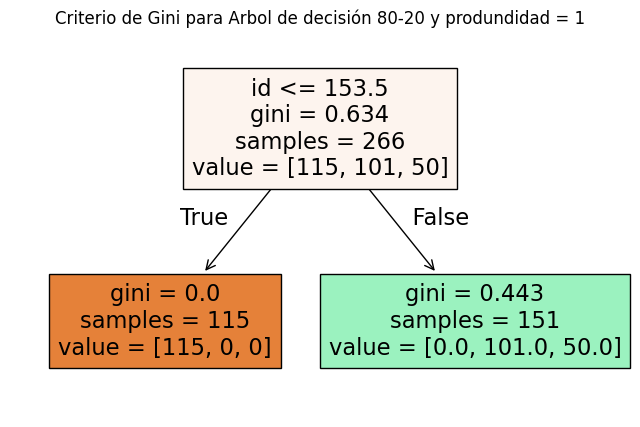

Precisión: 0.58
Recall: 0.7164179104477612
F1: 0.6276881540187651
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


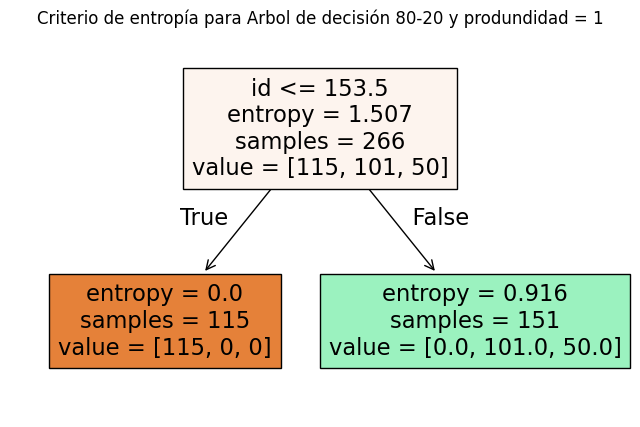

Precisión: 0.58
Recall: 0.7164179104477612
F1: 0.6276881540187651
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [30]:
arbol4 = arbol(0.20, 1, 'Arbol de decisión 80-20 y produndidad = 1')

Se entrena el segundo árbol considerando la división de entrenamiento y prueba de 80-20 y produndidad del árbol igual a 2.

Arbol de decisión 80-20 y produndidad = 2
Muestras de entrenamiento X: 266
Muestras de prueba X: 67
Muestras de entrenamiento y: 266
Muestras de prueba y: 67


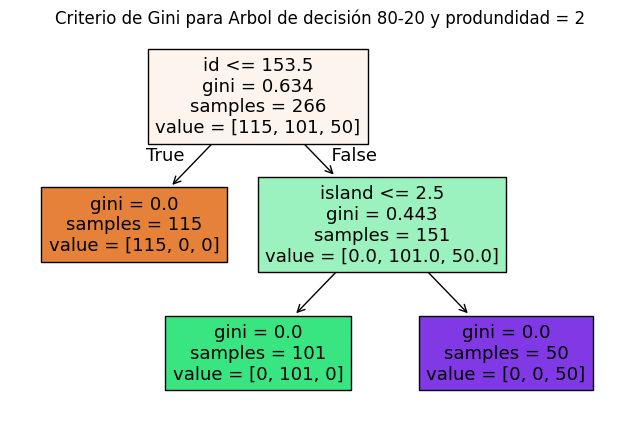

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


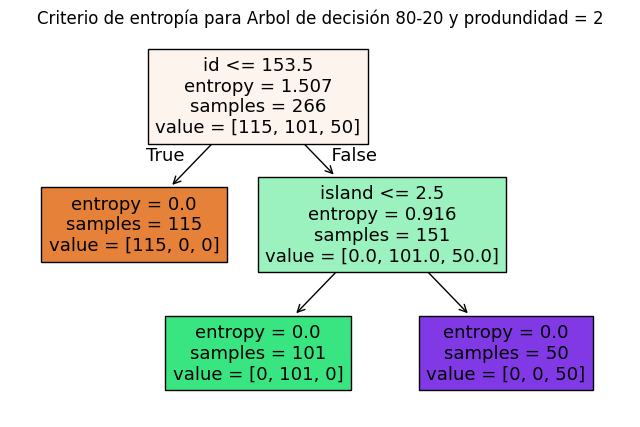

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [31]:
arbol5 = arbol(0.20, 2, 'Arbol de decisión 80-20 y produndidad = 2')

Se entrena el tercer árbol considerando la división de entrenamiento y prueba de 80-20 y produndidad del árbol igual a 3.

Arbol de decisión 80-20 y produndidad = 3
Muestras de entrenamiento X: 266
Muestras de prueba X: 67
Muestras de entrenamiento y: 266
Muestras de prueba y: 67


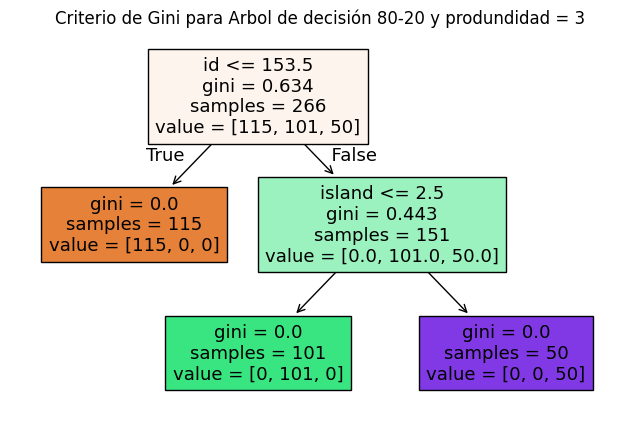

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


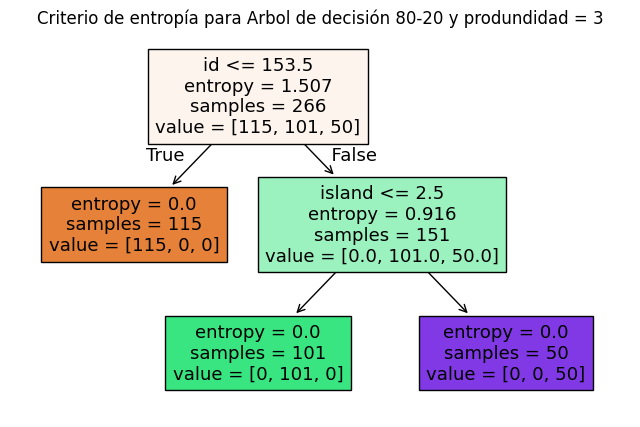

Precisión: 0.99
Recall: 0.9850746268656716
F1: 0.9849798625918028
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [32]:
arbol6 = arbol(0.20, 3, 'Arbol de decisión 80-20 y produndidad = 3')

## Árboles con división 70-30

Se entrena el primer árbol considerando la división de entrenamiento y prueba de 70-30 y produndidad del árbol igual a 1.

Arbol de decisión 70-30 y produndidad = 1
Muestras de entrenamiento X: 233
Muestras de prueba X: 100
Muestras de entrenamiento y: 233
Muestras de prueba y: 100


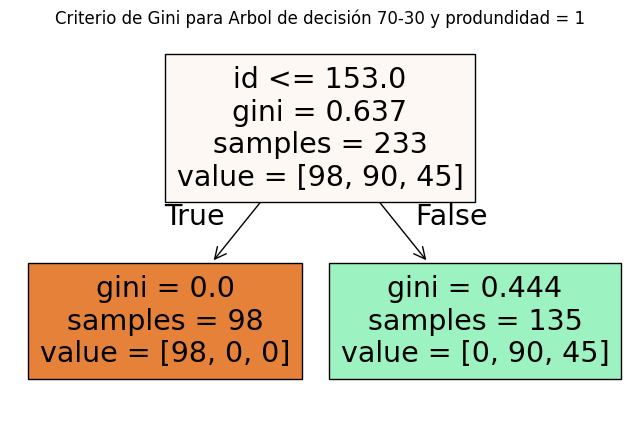

Precisión: 0.63
Recall: 0.76
F1: 0.6780515463917526
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


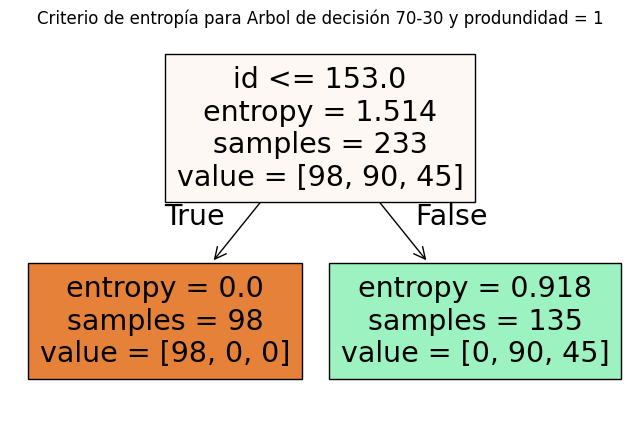

Precisión: 0.63
Recall: 0.76
F1: 0.6780515463917526
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [33]:
arbol7 = arbol(0.30, 1, 'Arbol de decisión 70-30 y produndidad = 1')

Se entrena el segundo árbol considerando la división de entrenamiento y prueba de 70-30 y produndidad del árbol igual a 2.

Arbol de decisión 70-30 y produndidad = 2
Muestras de entrenamiento X: 233
Muestras de prueba X: 100
Muestras de entrenamiento y: 233
Muestras de prueba y: 100


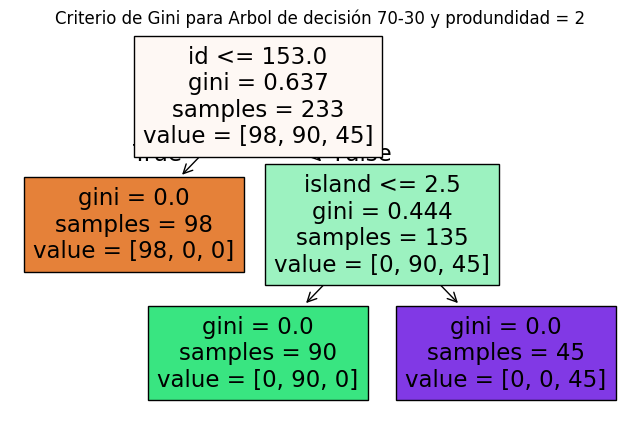

Precisión: 0.99
Recall: 0.99
F1: 0.9899638270935069
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


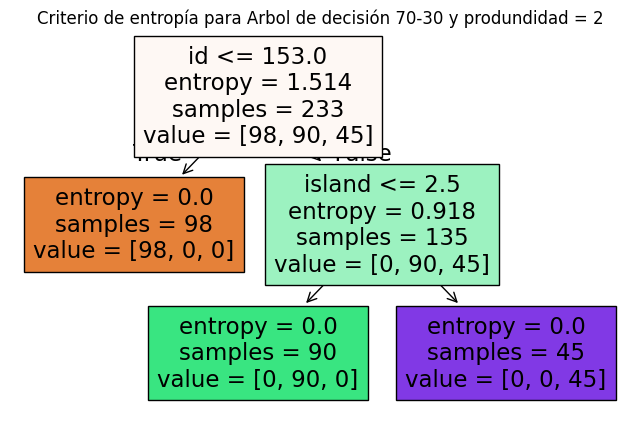

Precisión: 0.99
Recall: 0.99
F1: 0.9899638270935069
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [34]:
arbol8 = arbol(0.30, 2, 'Arbol de decisión 70-30 y produndidad = 2')

Se entrena el tercer árbol considerando la división de entrenamiento y prueba de 70-30 y produndidad del árbol igual a 3.

Arbol de decisión 70-30 y produndidad = 3
Muestras de entrenamiento X: 233
Muestras de prueba X: 100
Muestras de entrenamiento y: 233
Muestras de prueba y: 100


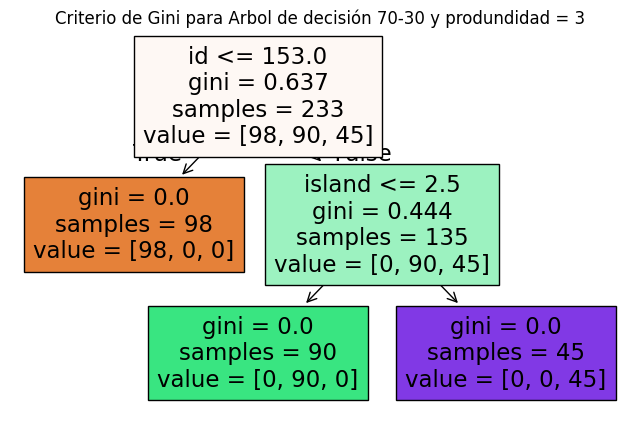

Precisión: 0.99
Recall: 0.99
F1: 0.9899638270935069
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


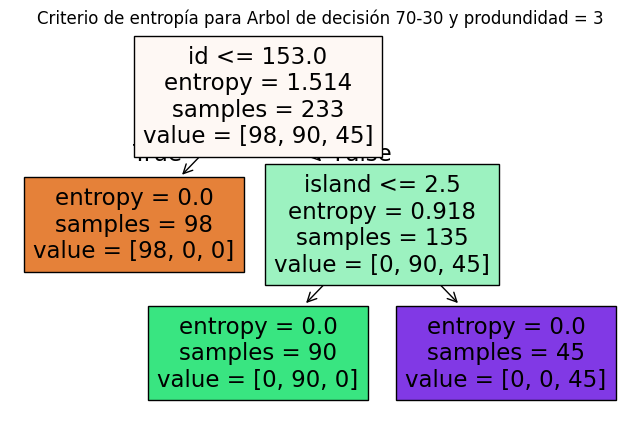

Precisión: 0.99
Recall: 0.99
F1: 0.9899638270935069
Support: species
1    146
2    119
3     68
Name: count, dtype: int64


In [35]:
arbol9 = arbol(0.30, 3, 'Arbol de decisión 70-30 y produndidad = 3')

## Conclusión
Para concluir, se puede observar que para las tres combinaciones de división de conjunto de entrenamiento y de prueba, los árboles con profundidad 2 y 3 son iguales, esto debido a que basta con la profunididad de 2 para que el modelo aprenda y funcione correctamente. Además, la profunidad 1 para los tres casos tiene muy poca precisión.   
También, para los tres casos se observa que el criterio de Gini y el criterio de Entropía dan los mismos resultados al momento de evaluarlos con las métricas. Entonces, el árbol con mayor precisión, sencibilidad y puntuación de f1 son ambos criterio de Gini y Entropía para la división de datos 70% entrenamiento y 30% prueba. 